## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pickle
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 데이터 로드

In [2]:
df = pd.read_csv('../data/CICIDS2017/Monday-WorkingHours.pcap_ISCX.csv')
print(df.shape)
print(df.columns.tolist())
print(df[' Label'].value_counts())

(529918, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count'

## 정상 데이터만 분리

In [3]:
df.columns = df.columns.str.strip()
normal_df = df[df['Label'] == 'BENIGN'].copy()
print("정상 데이터 shape:", normal_df.shape)

정상 데이터 shape: (529918, 79)


## 피처 선택 및 전처리 과정

In [4]:
# 불필요한 컬럼 제거
drop_cols = ['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
feature_df = normal_df.drop(columns=[c for c in drop_cols if c in normal_df.columns])

# 무한대/결측치 제거
feature_df.replace([np.inf, -np.inf], np.nan, inplace=True)
feature_df.dropna(inplace=True)

print("전처리 후 shape:", feature_df.shape)
print("피처 수:", feature_df.shape[1])

전처리 후 shape: (529481, 78)
피처 수: 78


## 스케일링 및 저장

In [5]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(feature_df)

os.makedirs('../models', exist_ok=True)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("스케일링 완료:", scaled_data.shape)

스케일링 완료: (529481, 78)


## 3 Sliding Window (3D 텐서 변환)

In [9]:
def create_sequences(data, window_size=10):
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
    return np.array(sequences)

WINDOW_SIZE = 10
X = create_sequences(scaled_data, WINDOW_SIZE)
print("3D 텐서 shape:", X.shape)
# 결과: (samples, 10, 78) 이어야 함

3D 텐서 shape: (529471, 10, 78)


## Train/Validation 분리

In [8]:
X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (476523, 10, 78)
Val shape: (52948, 10, 78)


## LSTM Autoencoder 모델 설계

In [10]:
def build_autoencoder(timesteps, features):
    inputs = Input(shape=(timesteps, features))
    
    # Encoder
    encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)
    
    # 압축된 표현을 다시 시퀀스로 복원
    repeated = RepeatVector(timesteps)(encoded)
    
    # Decoder
    decoded = LSTM(64, activation='relu', return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(features))(decoded)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_autoencoder(WINDOW_SIZE, X_train.shape[2])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 78)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        36,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 78)         │         5,070 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,702 (291.80 KB)

 Trainable params: 74,702 (291.80 KB)

 Non-trainable params: 0 (0.00 B)

## 모델 학습

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 199s 44ms/step - loss: 0.0108 - val_loss: 0.0085
Epoch 2/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - loss: 0.0078 - val_loss: 0.0070
Epoch 3/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 4/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 5/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0037 - val_loss: 0.0032
Epoch 6/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 7/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 8/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 10/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 11/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 1

## 모델 저장

In [15]:
model.save('../models/deepguard_model.keras')
print("모델 저장 완료")

모델 저장 완료


## 임계값 (Threshold) 산출

In [16]:
X_pred = model.predict(X_val, verbose=0)
mse = np.mean(np.square(X_val - X_pred), axis=(1, 2))

threshold = np.percentile(mse, 95)
print(f"재구성 오차 평균: {np.mean(mse):.6f}")
print(f"임계값 (95th percentile): {threshold:.6f}")

with open('../models/threshold.pkl', 'wb') as f:
    pickle.dump(threshold, f)
print("임계값 저장 완료")

재구성 오차 평균: 0.001087
임계값 (95th percentile): 0.002946
임계값 저장 완료


## 임계값 시각화

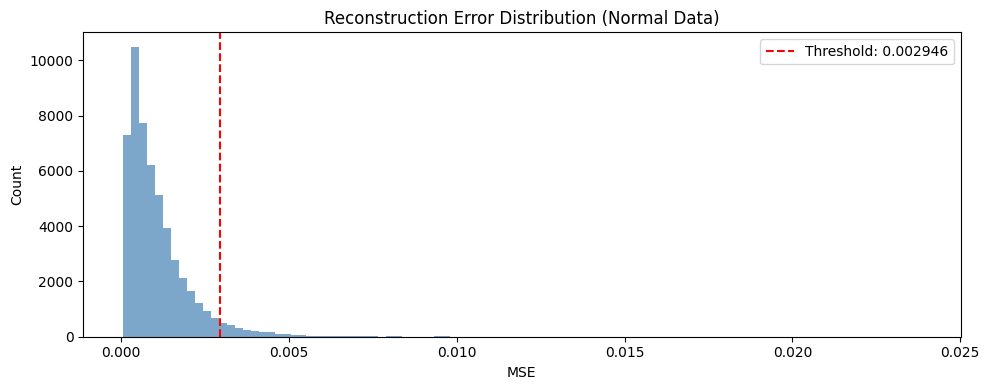

In [17]:
plt.figure(figsize=(10, 4))
plt.hist(mse, bins=100, color='steelblue', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.6f}')
plt.xlabel('MSE')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution (Normal Data)')
plt.legend()
plt.tight_layout()
plt.savefig('../models/threshold_plot.png')
plt.show()